<a href="https://colab.research.google.com/github/abdullahpi912/InternshipProgress/blob/main/Phase-2/Day17/EDA_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 17 - Exploratory Data Analysis (EDA) using Matplotlib & Seaborn
**Dataset:** Titanic Dataset

**Objective:** Explore the Titanic dataset using Matplotlib and Seaborn to understand passenger demographics, fare distribution, and survival patterns through different types of visualizations.

## 1. Load Libraries and Dataset
We use Seaborn's built-in Titanic dataset, which comes preloaded with passenger details like age, fare, class, and survival status. Rows with missing age, fare, or embarkation data are dropped so every chart works on complete records.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_style("whitegrid")

df = sns.load_dataset("titanic")
df = df.dropna(subset=["age", "fare", "embarked"])

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (712, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Line Plot - Average Fare by Age

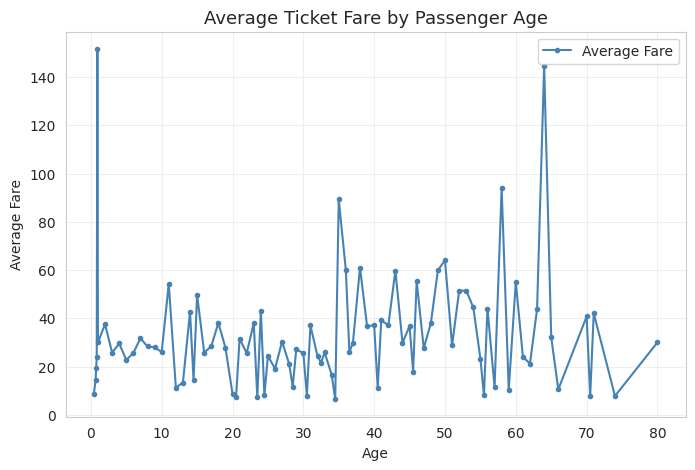

In [2]:
age_fare = df.groupby("age")["fare"].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(age_fare["age"], age_fare["fare"], color="steelblue", marker="o",
         markersize=3, linewidth=1.5, label="Average Fare")
plt.title("Average Ticket Fare by Passenger Age", fontsize=13)
plt.xlabel("Age")
plt.ylabel("Average Fare")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Why this chart:** A line plot is suited to showing how a numeric value changes across a continuous variable like age.

**What it represents:** The average fare paid by passengers at each age.

**Insights:** Average fare doesn't rise steadily with age. There are sharp spikes at certain ages (often older passengers), which likely reflects a few wealthy individuals in first class rather than a real age-fare trend, since the mean is easily skewed by outliers at ages with very few passengers.

## 3. Bar Chart - Average Fare by Passenger Class

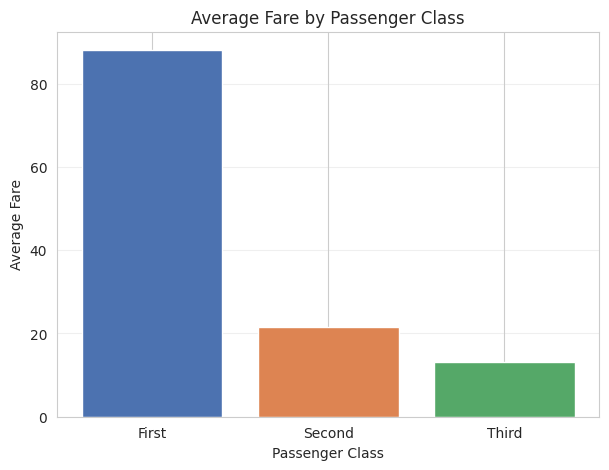

In [3]:
class_fare = df.groupby("class", observed=True)["fare"].mean().reset_index()

plt.figure(figsize=(7, 5))
plt.bar(class_fare["class"], class_fare["fare"], color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

**Why this chart:** A bar chart is the standard way to compare a numeric value across a small number of categories.

**What it represents:** The average ticket fare paid within each passenger class (First, Second, Third).

**Insights:** First class fares are far higher on average than Second and Third class, confirming fare is a strong proxy for class and, indirectly, for wealth and survival likelihood.

## 4. Histogram - Distribution of Passenger Age

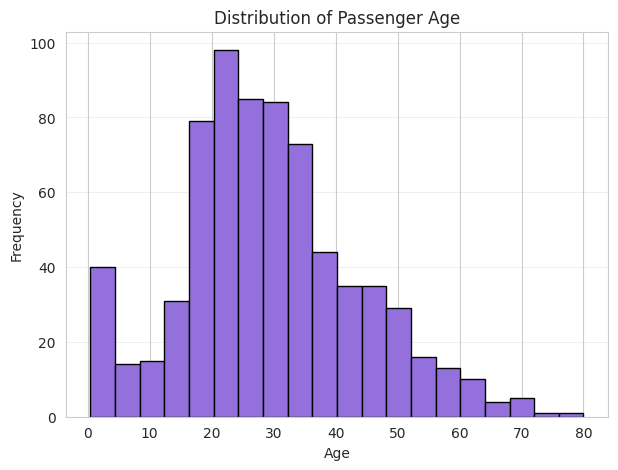

In [4]:
plt.figure(figsize=(7, 5))
plt.hist(df["age"], bins=20, color="mediumpurple", edgecolor="black")
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

**Why this chart:** A histogram shows how a single numeric variable is distributed across its range.

**What it represents:** How many passengers fall into each age bracket.

**Insights:** Most passengers are between 20 and 40 years old, with a smaller secondary bump for young children. Very few elderly passengers were aboard.

## 5. Scatter Plot - Age vs Fare (colored by Survival)

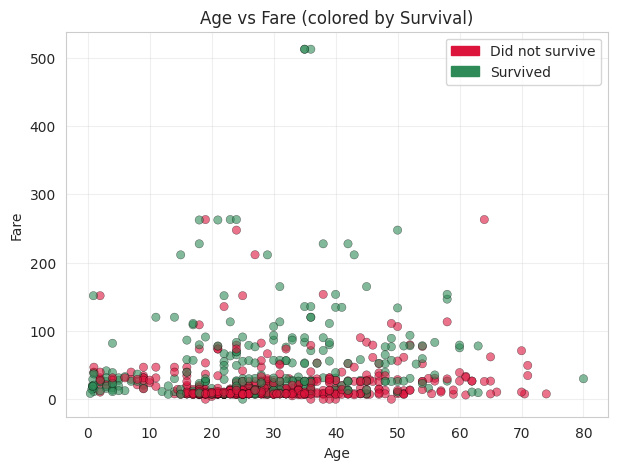

In [5]:
colors = df["survived"].map({0: "crimson", 1: "seagreen"})

plt.figure(figsize=(7, 5))
plt.scatter(df["age"], df["fare"], c=colors, alpha=0.6, edgecolor="k", linewidth=0.3)
plt.title("Age vs Fare (colored by Survival)")
plt.xlabel("Age")
plt.ylabel("Fare")
legend_handles = [mpatches.Patch(color="crimson", label="Did not survive"),
                  mpatches.Patch(color="seagreen", label="Survived")]
plt.legend(handles=legend_handles)
plt.grid(True, alpha=0.3)
plt.show()

**Why this chart:** A scatter plot reveals the relationship between two numeric variables, and coloring by a third categorical variable adds an extra layer of insight.

**What it represents:** Each point is a passenger, plotted by age and fare, colored by whether they survived.

**Insights:** Passengers who paid higher fares (upper portion of the plot) show a noticeably higher concentration of green (survived) points, reinforcing that wealthier, higher-class passengers had better survival odds regardless of age.

## 6. Box Plot - Fare Distribution by Class

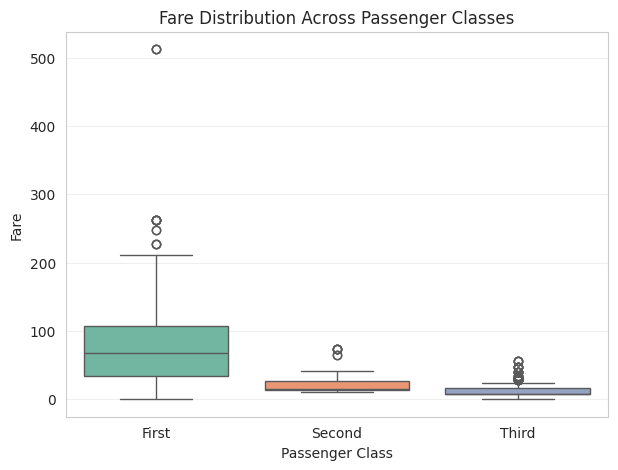

In [6]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="class", y="fare", data=df, hue="class", palette="Set2", legend=False)
plt.title("Fare Distribution Across Passenger Classes")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

**Why this chart:** A box plot summarizes spread, median, and outliers for a numeric variable across categories in one view.

**What it represents:** The median, interquartile range, and outlier fares within each passenger class.

**Insights:** First class has both a higher median fare and far more high-value outliers than Second or Third class, showing wide fare variation even within the same class, likely due to cabin type or family size.

## 7. Count Plot - Survival Count by Gender

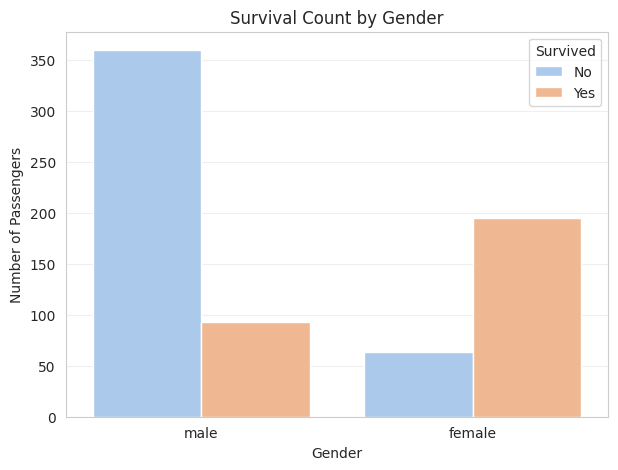

In [7]:
plt.figure(figsize=(7, 5))
sns.countplot(x="sex", hue="survived", data=df, palette="pastel")
plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.grid(True, axis="y", alpha=0.3)
plt.show()

**Why this chart:** A count plot is ideal for showing frequency counts across categorical variables.

**What it represents:** The number of male and female passengers who did and did not survive.

**Insights:** Female passengers survived at a much higher rate than male passengers, who made up the majority of the dataset but had a much lower survival count. This is one of the clearest patterns in the entire dataset.

## 8. Bonus - Pair Plot

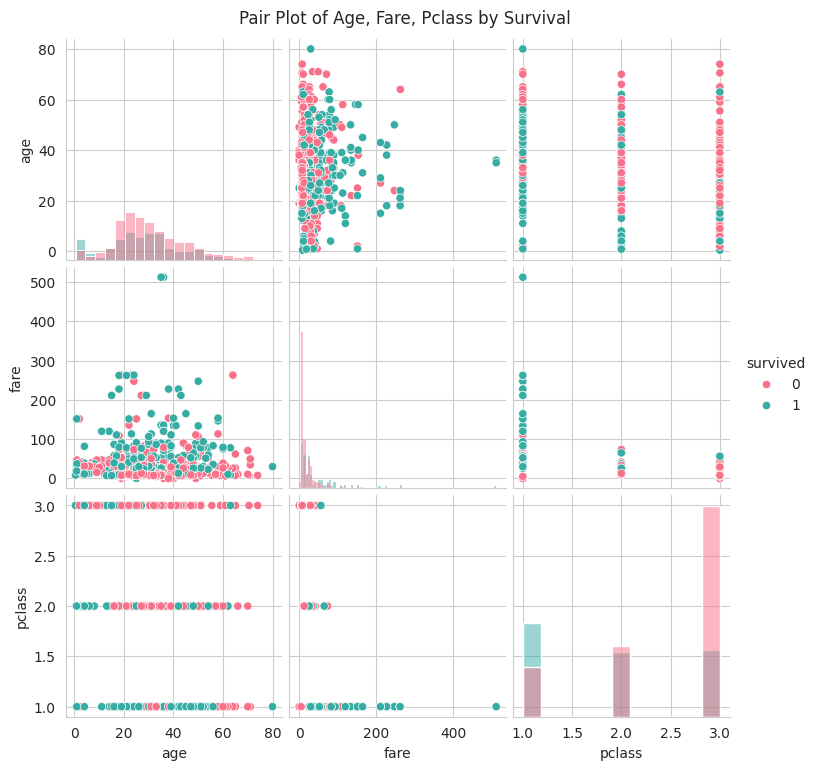

In [8]:
subset = df[["age", "fare", "pclass", "survived"]]

g = sns.pairplot(subset, hue="survived", palette="husl", diag_kind="hist")
g.fig.suptitle("Pair Plot of Age, Fare, Pclass by Survival", y=1.02)
plt.show()

**Why this chart:** A pair plot lets us scan every pairwise relationship between numeric variables at once, which is faster than building each scatter plot individually.

**What it represents:** Pairwise relationships between age, fare, and passenger class, split by survival.

**Insights:** The fare vs pclass panel confirms the strong inverse relationship between class number and fare. The diagonal histograms show survivors (in a different hue) are shifted toward lower pclass values and higher fares compared to non-survivors.

## 9. Summary of Key Insights
- **Fare and class are the strongest survival predictors.** Higher fare and lower class number (First class) both line up with better survival odds.
- **Gender is the single clearest survival signal.** Female passengers survived at a much higher rate than male passengers.
- **Age is concentrated in the 20-40 range**, with a smaller cluster of young children.
- **Fare has heavy outliers within First class**, so the median tells a more reliable story than the mean for that group.
- Together, these visualizations suggest survival was shaped less by age and more by a combination of gender, class, and the fare paid.